1) Problem Statement:

The organization lacks structured insights into product performance and relationships, leading to suboptimal inventory planning and missed revenue opportunities.

The primary objective is to group similar products based on sales patterns, thereby discerning trends, optimizing inventory management processes, and tailoring our offerings to better align with customer preferences.

2) Identify Key Business Objectives

*   Group products based on sales behavior
*   Identify high-performing vs low-performing products
*   Discover product relationships(substitute/realated demand)
*   Improve Inventory planning,Product assortment and sales strategy

3) Define Key Business Questions

*   Which Products are top revenue drivers
*   Which products are slow-moving and dead stock
*   Which products show seasonal demand

4) Define Success Criteria

*   Reduction in overstock/ dead inventory
*   Increase in inventory turnover
*   Improved sales of bundled products
*   Better forecasting accuracy

5) Define Expected Deliverables
*   Product Clusters
*   Product relationship insights
*   Dashboard for exploration
*   Business Recommendation


“Success will be measured by improved inventory efficiency, increased sales through better product grouping, and actionable insights derived from clustering and product relationship analysis.

















## Step 1 - Importing Libraries, Loading Dataset & Basic Overview

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans,AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Dimensionality Reduction
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load Data and Basic Inspection
import pandas as pd

file_path = "/content/Warehouse_and_Retail_Sales.csv"
df = pd.read_csv(file_path)

# First look
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


## Step 2 - Data Exploration

In [ ]:
# Dataset Overview
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()

Shape: (307645, 9)

Columns: Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307478 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307644 non-null  object 
 6   RETAIL SALES      307642 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB


Dataset Overview:
Shape of Dataset- Rows: 307,645 & Columns: 9
This means the dataset is large with over 300k records. it is goof for Machine Learning, Pattern detection & Sales Analysis

Column-wise Explanation
1. Time Features
Year(int64) - Year of transaction
Month(int64) - Month of transaction

2. Product & Supplier Info
SUPPLIER (object) → Supplier name- Missing values: 167 rows
ITEM CODE (object) → Unique product ID
ITEM DESCRIPTION (object) → Product name/details
ITEM TYPE (object) → Category/type of product - Missing values: 1 row

3. Sales Metrics
RETAIL SALES (float64) - Missing values: 3 rows
RETAIL TRANSFERS (float64)
WAREHOUSE SALES (float64)

Key Observations:
Large dataset → strong insights possible
Minimal missing values
Multiple sales channels → rich analysis

Things to Handle
Missing values in SUPPLIER
Categorical variables need encoding
Possible outliers in sales

In [ ]:
# Summary Statistics- Understand distribution of numeric variables
df.describe()

,YEAR,MONTH,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
count,307645.000000,307645.000000,307642.000000,307645.000000,307645.000000
mean,2018.438525,6.423862,7.024071,6.936465,25.294597
std,1.083061,3.461812,30.986238,30.237195,249.916798
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.320000,0.000000,1.000000
75%,2019.000000,9.000000,3.267500,3.000000,5.000000
max,2020.000000,12.000000,2739.000000,1990.830000,18317.000000


Observations:
Time Feature Analysis:
YEAR - Range between 2017- 2020, Mean ~2018.4, Data Spans ~3-4 years
MONTH - Range 1-12 , Mean 6.42. Full yearly cycle present

Sales Columns Analysis
RETAIL SALES- Mean: 7.02,Median: 0.32,Max:2739,Min: -6.49
Median << Mean → Highly right-skewed, Many values near 0
Few very large values(outliers)
Interpretation:
Most products sell very little
Few products generate high sales(top performers)

RETAIL TRANSFERS- Mean: 6.93, Median 0, Max: 1990.83, Min: -38.49
Median = 0 → many no-transfer cases, Presence of negative values
Interpretation:
Transfers are not consistent
Likely used for inventory balancing

WAREHOUSE SALES- Mean: 25.29, Median: 1, Max: 18,317, Min: -7800
Extremely large range, Very high standard deviation (249) & string outliers
Interpretation
Warehouse handles bulk movement possibly because of returns,Adjustments and Data anomalies



In [ ]:
# Missing Value Analysis
df.isnull().sum().sort_values(ascending=False)

,0
SUPPLIER,167
RETAIL SALES,3
ITEM TYPE,1
YEAR,0
MONTH,0
ITEM DESCRIPTION,0
ITEM CODE,0
RETAIL TRANSFERS,0
WAREHOUSE SALES,0


Supplier column has 167 missing values, Retail Sales has 3 and Item Type has 1 missing values

In [ ]:
# Unique Values- Categorical Understanding
df.nunique().sort_values(ascending=False)

,0
ITEM DESCRIPTION,34822
ITEM CODE,34056
RETAIL SALES,10674
WAREHOUSE SALES,4895
RETAIL TRANSFERS,2504
SUPPLIER,396
MONTH,12
ITEM TYPE,8
YEAR,4


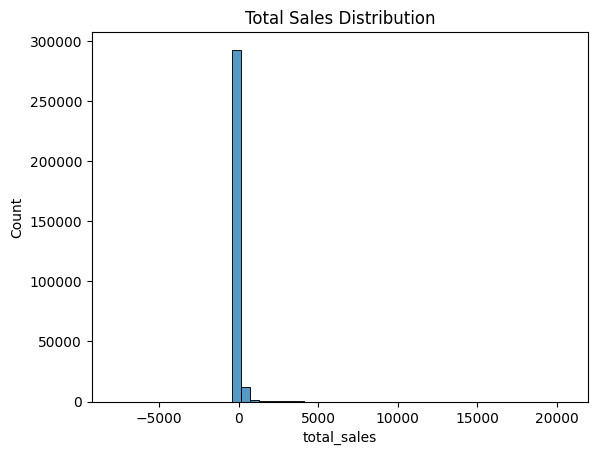

In [ ]:
# Sales Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales by summing relevant sales columns
df['total_sales'] = df['RETAIL SALES'] + df['RETAIL TRANSFERS'] + df['WAREHOUSE SALES']

sns.histplot(df['total_sales'], bins=50)
plt.title("Total Sales Distribution")
plt.show()

Observations:
1) Heavy Right Skew- Majority of products have low sales
2)  Few products dominate revenue
3) Presence of Outliers- Extreme high values strect the distribution
4) Negative Values- Sales should not usually be negative

If data is skewed, Large values dominate clustering, Small products get ignored

To fix this, we need to do the following
1) Handle Negative Values - It represent reverse transactions, not actual demand
2) Apply Log Transformation - To reduce Skewness,Control Outliers and to have better grouping of clusters
3) Handle Outliers- Dominance of large values leads to misleading patterns and poor model performance
4) Rebuild features using Transformed data-transformed messy sales data into structured signals that ML can actually understand

In [ ]:
# Handle Negative Values
# Check negative values
df[df['total_sales'] < 0].head()

# Option 1: Remove them
df = df[df['total_sales'] >= 0]

# Option 2 (better if returns matter):
# df['total_sales'] = df['total_sales'].clip(lower=0)

Key Observations from Log-Transformed Distribution

1. Skewness is greatly reduced, distribution is much more spread out and shape is closer to normal(bell-like)

2. Better Data Spread- Values now range between 0 to 10. Differences between products are now visible and comparable

3. Dense Region Around 1-3. Most data points lie between log values 1 to 3. Majority of your products are still low performers (expected in retail)

4. Long Tail Still Exists (But Controlled). High-performing products still exist. But they no longer dominate the dataset

5. Outliers Are Now Managed. Model will treat all data more fairly


In [ ]:
# Handle Outliers
# Remove top 1% extreme values
q_high = df['total_sales'].quantile(0.99)

df = df[df['total_sales'] <= q_high]

The distribution of total sales was highly right-skewed, with a small number of products contributing disproportionately to overall sales. To address this, a log transformation was applied to normalize the data, improving clustering performance and reducing the impact of outliers

## Step 3 - Data Cleaning

In [ ]:
# Handle Missing Values
df.isnull().sum().sort_values(ascending=False)

,0
SUPPLIER,90
ITEM TYPE,1
MONTH,0
YEAR,0
ITEM CODE,0
ITEM DESCRIPTION,0
RETAIL SALES,0
RETAIL TRANSFERS,0
WAREHOUSE SALES,0
total_sales,0


In [ ]:
# Converting Column names to Lowercase
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('[^a-z0-9_]', '', regex=True)
)

In [ ]:
# Fill Nan values with "Unknown"
df['supplier'] = df['supplier'].fillna("Unknown")

In [ ]:
# Fix Data Types -Convert to Numeric
numeric_cols = ['retail_sales', 'warehouse_sales', 'total_sales']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
# Remove Duplicates
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


In [ ]:
# Handle Negative Values
df[df['total_sales'] < 0]

,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales,total_sales


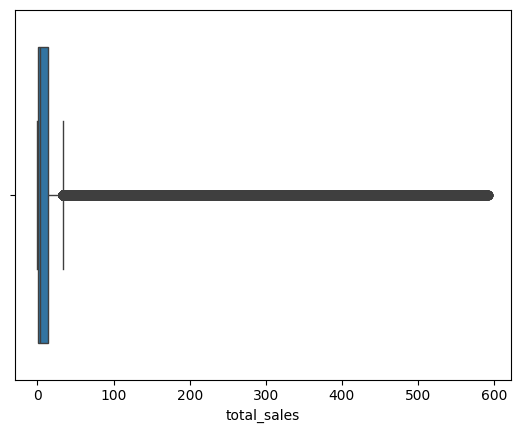

In [ ]:
# Handle Outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['total_sales'])
plt.show()

Observations:

1) Extremely Compressed Box (Near Zero). The box (IQR) is very small and close to 0, Median is also near very low values. Most of your products have very low total sales

2) Median Near Bottom. At least 50% of products sell very little

3) Massive Number of Outliers- Huge stretch of points extending up to 600. A small number of products have very high sales

4) Strong Right Skew, Left side (low values) is dense, Right side (high values) is sparse. data is not normally distributed



In [ ]:
# Remove Extreme Values
q_low = df['total_sales'].quantile(0.01)
q_high = df['total_sales'].quantile(0.99)

df = df[(df['total_sales'] >= q_low) & (df['total_sales'] <= q_high)]

In [ ]:
# Fix Skewness

# Ensure underlying sales columns are non-negative before log transformation
df['retail_sales'] = df['retail_sales'].clip(lower=0)
df['retail_transfers'] = df['retail_transfers'].clip(lower=0)
df['warehouse_sales'] = df['warehouse_sales'].clip(lower=0)

df['log_total_sales'] = np.log1p(df['total_sales'])
df['log_retail_sales'] = np.log1p(df['retail_sales'])
df['log_warehouse_sales'] = np.log1p(df['warehouse_sales'])

In [ ]:
# Standardize Text Columns
df['supplier'] = df['supplier'].str.strip().str.lower()
df['item_type'] = df['item_type'].str.strip().str.lower()

In [ ]:
# Validate Data Consistency
df[
    df['total_sales'] != (
        df['retail_sales'] +
        df['retail_transfers'] +
        df['warehouse_sales']
    )
]

,year,month,supplier,item_code,item_description,item_type,retail_sales,retail_transfers,warehouse_sales,total_sales,log_total_sales,log_retail_sales,log_warehouse_sales
2215,2020,1,north lock llc dba port city brewing co,25738,PORT CITY MONUMENTAL IPA 4/6 12 OZ,beer,3.25,0.0,17.0,19.25,3.008155,1.446919,2.890372
4694,2020,1,constantine wines inc,336527,UNDERWOOD ROSE - 750ML,wine,0.00,0.0,2.0,1.66,0.978326,0.000000,1.098612
6487,2020,1,"the country vintner, llc dba winebow",384534,CH MUSAR JEUNE RGE - 750ML,wine,0.00,0.0,1.0,0.83,0.604316,0.000000,0.693147
10606,2020,1,front porch micro winery llc,80214,THE WINERY AT OLNEY PEACH CHARD - 750ML,wine,0.48,3.0,0.0,1.48,0.908259,0.392042,0.000000
11696,2020,1,sazerac co,92140,FIREBALL CINNAMON WHISKY PET - 1.75L,liquor,2.20,0.0,0.0,1.20,0.788457,1.163151,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
291487,2019,11,reliable churchill lllp,39705,LITTLE PENGUIN SHZ - 1.5L,wine,2.68,0.0,0.0,1.68,0.985817,1.302913,0.000000
292834,2019,11,pwswn inc,48512,BULGARIANA CAB/SYR 329148 - 750ML,wine,0.00,1.0,0.0,0.83,0.604316,0.000000,0.000000
293084,2019,11,deutsch family wine & spirits,50903,VILLA MASSA LIMONI - 750ML,liquor,8.10,0.0,0.0,7.10,2.091864,2.208274,0.000000
297121,2019,11,dogfish head craft brewery llc,99023,DOGFISH HEAD PUNKIN ALE 4/6 NR - 12OZ,beer,4.62,0.0,3.0,4.62,1.726332,1.726332,1.386294


In [ ]:
# Create Clean Dataset
df_cleaned = df.copy()

In [ ]:
# Final Check
df_cleaned.info()
df_cleaned.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 299020 entries, 0 to 307644
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 299020 non-null  int64  
 1   month                299020 non-null  int64  
 2   supplier             299020 non-null  object 
 3   item_code            299020 non-null  object 
 4   item_description     299020 non-null  object 
 5   item_type            299019 non-null  object 
 6   retail_sales         299020 non-null  float64
 7   retail_transfers     299020 non-null  float64
 8   warehouse_sales      299020 non-null  float64
 9   total_sales          299020 non-null  float64
 10  log_total_sales      299020 non-null  float64
 11  log_retail_sales     299020 non-null  float64
 12  log_warehouse_sales  299020 non-null  float64
dtypes: float64(7), int64(2), object(4)
memory usage: 31.9+ MB


,year,month,retail_sales,retail_transfers,warehouse_sales,total_sales,log_total_sales,log_retail_sales,log_warehouse_sales
count,299020.000000,299020.000000,299020.000000,299020.000000,299020.000000,299020.000000,299020.000000,299020.000000,299020.000000
mean,2018.439810,6.420587,4.812400,4.765564,8.235905,17.812381,1.809097,0.834752,1.153759
std,1.082205,3.463565,12.787108,13.064029,24.601744,39.804647,1.352000,1.128010,1.206639
min,2017.000000,1.000000,0.000000,0.000000,0.000000,0.080000,0.076961,0.000000,0.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.693147,0.000000,0.000000
50%,2019.000000,7.000000,0.290000,0.000000,1.000000,3.000000,1.386294,0.254642,0.693147
75%,2019.000000,9.000000,3.020000,3.000000,5.000000,13.270000,2.658159,1.391282,1.791759
max,2020.000000,12.000000,186.370000,268.000000,323.000000,323.250000,5.781515,5.233085,5.780744


In [ ]:
# Final Cleaning Fix
# Step 1 - Fix item_type
df['item_type'] = df['item_type'].fillna('unknown')

## Step 4- Feature Engineering

In [ ]:
def feature_engineering(df):

    pf = df_cleaned.groupby('item_code').agg({
        'total_sales': ['sum', 'mean', 'std'],
        'retail_sales': ['sum'],
        'warehouse_sales': ['sum'],
        'month': 'nunique'
    }).reset_index()

    pf.columns = [
        'item_code',
        'total_sales_sum',
        'total_sales_avg',
        'sales_variability',
        'retail_sales_sum',
        'warehouse_sales_sum',
        'active_months'
    ]

    pf.fillna(0, inplace=True)

    pf['sales_per_month'] = pf['total_sales_sum'] / (pf['active_months'] + 1)
    pf['retail_ratio'] = pf['retail_sales_sum'] / (pf['total_sales_sum'] + 1)
    pf['warehouse_ratio'] = pf['warehouse_sales_sum'] / (pf['total_sales_sum'] + 1)
    pf['cv_sales'] = pf['sales_variability'] / (pf['total_sales_avg'] + 1)

    return pf

## Exploratory Data Analysis

In [ ]:
# Top Product Analysis
top_products = df.groupby('item_description')['total_sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products

,total_sales
item_description,
SUTTER HOME WH/ZIN - 187ML,6521.28
BAREFOOT CEL P/GRIG - 187ML,6503.11
MICKEYS MALT 32OZ NR - 32OZ,6353.42
SUTTER HOME MER - 187ML,6293.40
SUTTER HOME CAB - 187ML,6162.57
DEVILS BACKBONE VIENNA LAGER 4/6NR - 12OZ,5997.30
SONOMA CUTRER RR CHARD - 750ML,5599.23
LEFFE BRUNE 4/6NR - 11.2 OZ,5546.01
SCHLITZ MALT 2/12 CAN - 12OZ,5530.67


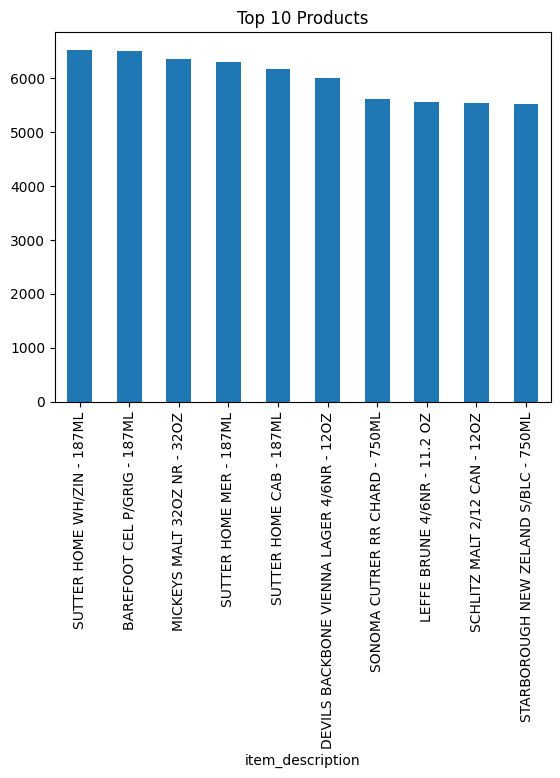

In [ ]:
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

In [ ]:
# Supplier Analysis
supplier_sales = df.groupby('supplier')['total_sales'].sum() \
                   .sort_values(ascending=False)

supplier_sales.head(10)

,total_sales
supplier,
e & j gallo winery,448090.51
anheuser busch inc,378498.88
constellation brands,281774.84
diageo north america inc,270514.42
miller brewing company,211859.54
the wine group,180346.84
jim beam brands co,152221.67
sazerac co,117227.14
boston beer corporation,111743.10


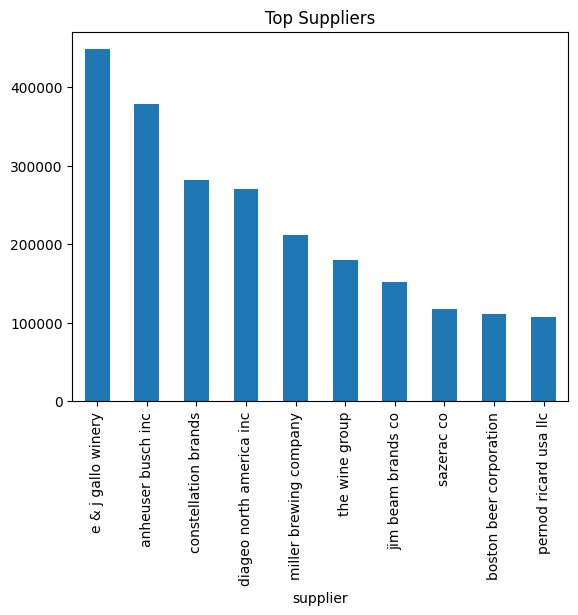

In [ ]:
supplier_sales.head(10).plot(kind='bar')
plt.title("Top Suppliers")
plt.show()

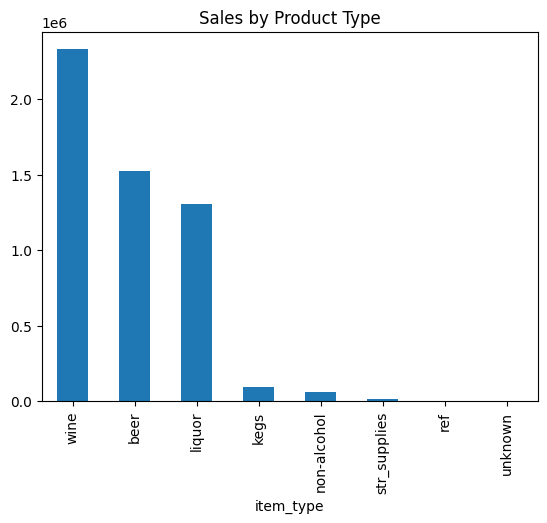

In [ ]:
# Product Type Analysis
type_sales = df.groupby('item_type')['total_sales'].sum() \
               .sort_values(ascending=False)

type_sales.plot(kind='bar')
plt.title("Sales by Product Type")
plt.show()

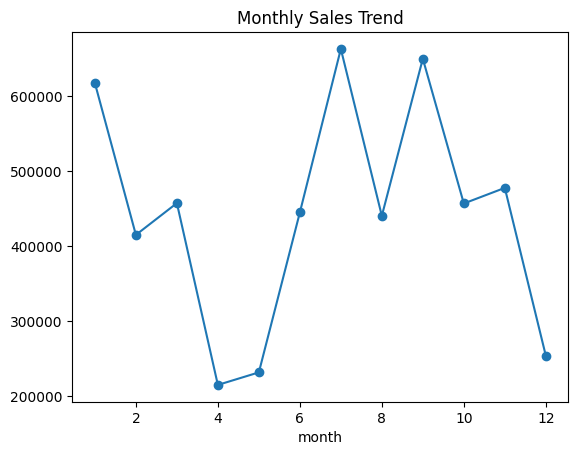

In [ ]:
# Monthly Trend
monthly_sales = df.groupby('month')['total_sales'].sum()

monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.show()

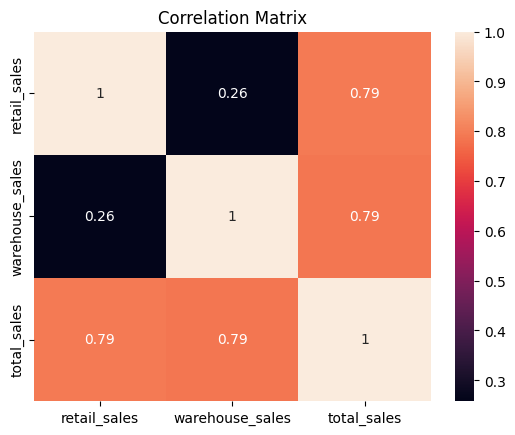

In [ ]:
# Correlation Analysis
corr = df[['retail_sales','warehouse_sales','total_sales']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

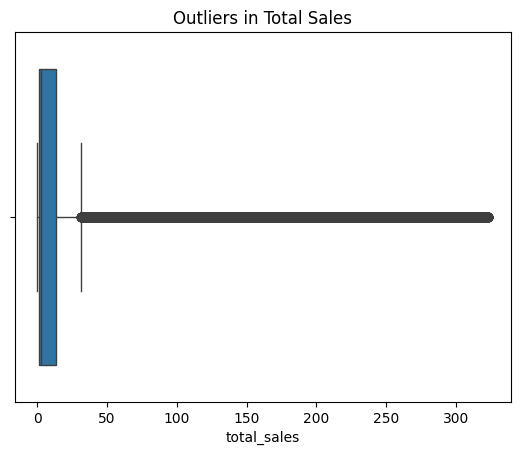

In [ ]:
# Outlier Detection
sns.boxplot(x=df['total_sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [ ]:
# Final Feature Selection
features = final_clusters.drop(['item_code'], axis=1)

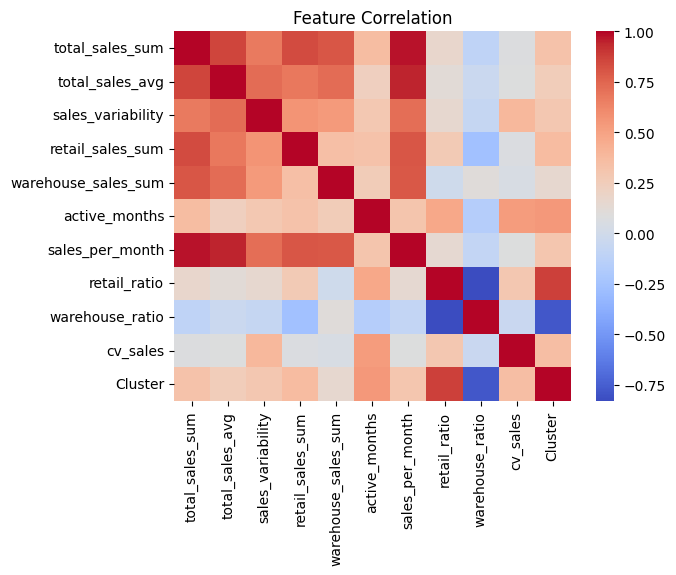

In [ ]:
# Correlation Check

sns.heatmap(features.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [ ]:
# Product Activity Analysis
product_activity = df.groupby('item_code')['month'].nunique()

product_activity.describe()

,month
count,33700.000000
mean,5.930356
std,4.310721
min,1.000000
25%,2.000000
50%,5.000000
75%,11.000000
max,12.000000


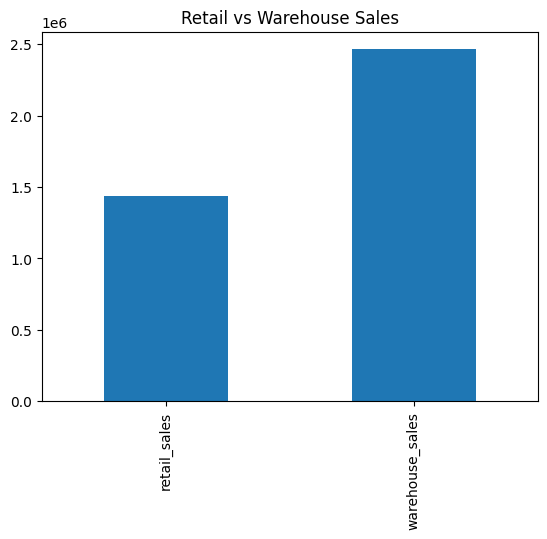

In [ ]:
# Sales Channel Comparison
df[['retail_sales','warehouse_sales']].sum().plot(kind='bar')
plt.title("Retail vs Warehouse Sales")
plt.show()

## Step 6 - Feature Scaling

In [ ]:
def select_features(pf):

    features = pf[
        ['sales_per_month', 'cv_sales', 'retail_ratio', 'warehouse_ratio', 'active_months']
    ]

    return features


In [ ]:
def scale_features(X):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler

## Step 7 -Model Selection



In [ ]:
def safe_silhouette(X, labels):

    if len(set(labels)) <= 1 or -1 in set(labels):
        return -1

    return silhouette_score(X, labels)

In [ ]:
def run_kmeans(X):

    best_score = -1
    best_labels = None
    best_k = None

    for k in range(2, 6):  # small range

        model = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = model.fit_predict(X)

        score = safe_silhouette(X, labels)

        if score > best_score:
            best_score = score
            best_labels = labels
            best_k = k

    return best_labels, best_score, best_k

In [ ]:
def run_agglomerative(X):

    best_score = -1
    best_labels = None

    for k in range(2, 6):

        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X)

        score = safe_silhouette(X, labels)

        if score > best_score:
            best_score = score
            best_labels = labels

    return best_labels, best_score

In [ ]:
def run_dbscan(X):

    best_score = -1
    best_labels = None

    for eps in [0.5, 1.0, 1.5]:

        model = DBSCAN(eps=eps, min_samples=5)
        labels = model.fit_predict(X)

        score = safe_silhouette(X, labels)

        if score > best_score:
            best_score = score
            best_labels = labels

    return best_labels, best_score

In [1]:
def plot_pca(X, labels, title):

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    df_plot = pd.DataFrame(X_pca, columns=['PCA1','PCA2'])
    df_plot['Cluster'] = labels

    plt.figure(figsize=(8,6))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_plot)

    plt.title(title)
    plt.show()

In [ ]:
def production_pipeline(df_cleaned):

    print("Feature Engineering...")
    pf = feature_engineering(df_cleaned)

    print("Feature Selection...")
    X = select_features(pf)

    print("Scaling...")
    X_scaled, scaler = scale_features(X)

    print("\nRunning K-Means...")
    k_labels, k_score, k_k = run_kmeans(X_scaled)

    print("Running Agglomerative...")
    a_labels, a_score = run_agglomerative(X_scaled)

    print("Running DBSCAN...")
    d_labels, d_score = run_dbscan(X_scaled)

    print("\nModel Scores:")
    print("KMeans:", k_score)
    print("Agglomerative:", a_score)
    print("DBSCAN:", d_score)

    # Best model selection
    best_model = max([
        ('KMeans', k_score, k_labels),
        ('Agglomerative', a_score, a_labels),
        ('DBSCAN', d_score, d_labels)
    ], key=lambda x: x[1])

    print("\nBest Model:", best_model[0])

    pf['Cluster'] = best_model[2]

    plot_pca(X_scaled, best_model[2], best_model[0])

    return pf

Feature Engineering...
Feature Selection...
Scaling...

Running K-Means...
Running Agglomerative...
Running DBSCAN...

Model Scores:
KMeans: 0.4588930168289839
Agglomerative: 0.45011686859971306
DBSCAN: -1

Best Model: KMeans


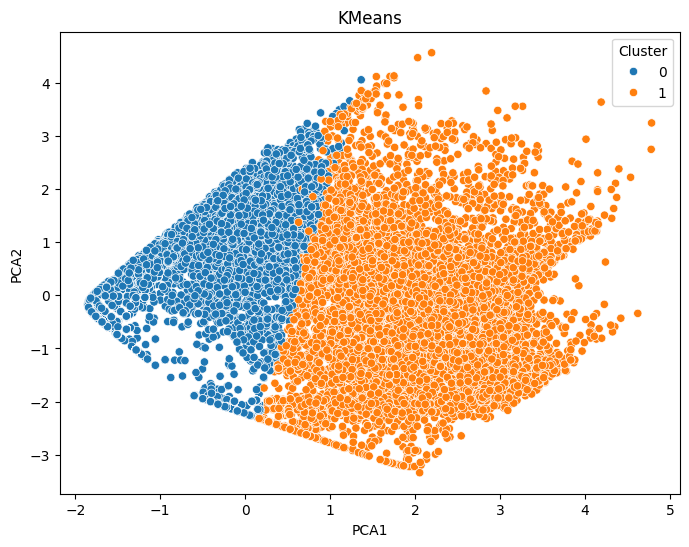

In [ ]:
final_clusters = production_pipeline(df_cleaned)

In [ ]:
# Check Explained Variance
# Re-run the necessary steps to get pca in this scope
pf_recomputed = feature_engineering(df_cleaned)
X_recomputed = select_features(pf_recomputed)
X_scaled_recomputed, _ = scale_features(X_recomputed)

pca_recomputed = PCA(n_components=2)
pca_recomputed.fit(X_scaled_recomputed)

print(pca_recomputed.explained_variance_ratio_)
print("Total variance explained:", sum(pca_recomputed.explained_variance_ratio_))

[0.4584401  0.25224629]
Total variance explained: 0.7106863845319678


In [ ]:
def plot_elbow(X):

    wcss = []

    K_range = range(2, 6)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)  # WCSS

    plt.figure(figsize=(8,5))
    plt.plot(K_range, wcss, marker='o')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("WCSS")
    plt.show()

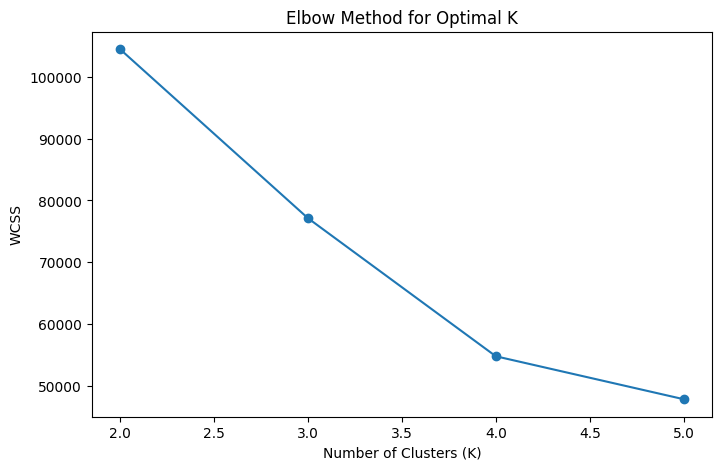

In [ ]:
plot_elbow(X_scaled_recomputed)

Observations:
The Elbow Method indicated potential cluster counts of 3 or 4; however, the Silhouette Score was highest for K = 2, indicating better cluster separation. Therefore, K = 2 was selected as the optimal number of clusters

In [2]:
import joblib

# Save trained model & scaler
joblib.dump(best_model, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

NameError: name 'best_model' is not defined